In [1]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
import xarray as xr
import json
#from joblib import Parallel, delayed
#import multiprocessing
import pandas as pd
import os
import sys
import csv 
import json
from datetime import datetime
import argparse
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
import utils as ut
import matplotlib.pyplot as plt

## Load absolute temperatures

In [2]:
ds_1300 = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_input_data/eth_test_trefht_data/TREFHT_day_b.e212.BHISTcmip6andSSP370cmip6.f09_g17.1300.nc")
ds_1400 = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_input_data/eth_test_trefht_data/TREFHT_day_b.e212.BHISTcmip6andSSP370cmip6.f09_g17.1400.nc")
ds_1500 = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_input_data/eth_test_trefht_data/TREFHT_day_b.e212.BHISTcmip6andSSP370cmip6.f09_g17.1500.nc")

ds_1300

<xarray.Dataset> Size: 20GB
Dimensions:    (time: 91615, bnds: 2, lon: 288, lat: 192)
Coordinates:
  * time       (time) object 733kB 1850-01-01 00:00:00 ... 2100-12-31 00:00:00
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 1MB ...
    TREFHT     (time, lat, lon) float32 20GB ...
Attributes:
    CDI:               Climate Data Interface version 1.9.6 (http://mpimet.mp...
    Conventions:       CF-1.0
    history:           Fri Sep 29 17:03:30 2023: cdo -O -mergetime /net/h2o/c...
    source:            CAM
    case:              b.e212.BHISTcmip6.f09_g17.1300
    logname:           beyerleu
    initial_file:      b.e212.B1850cmip6.f09_g17.001.cam.i.1300-01-01-00000.nc
    topography_file:   /cluster/work/climate/cesm/inputdata/atm/cam/topo/fv_0...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1
    CDO:               Climate Data Operators version 1.9.6 (http://mpimet.mp...

In [3]:
#ds_abs_test_pre = xr.concat([ds_1300, ds_1400, ds_1500], dim="member")

#ds_abs_test_pre = ds_abs_test_pre.assign_coords(
#    member=[1300, 1400, 1500]
#)


In [3]:
ds_abs_test_pre = ds_1300

ds_abs_test = ds_abs_test_pre.assign_coords(
    lon=((ds_abs_test_pre.lon + 180) % 360) - 180
).sortby("lon")

print(ds_abs_test)

# select germany domain TREFHT
### Germany ###
    
# coordinates 
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15

# cut data to GER domain
trefht_abs_test_ger_pre = ds_abs_test.TREFHT.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))
print(trefht_abs_test_ger_pre)



<xarray.Dataset> Size: 20GB
Dimensions:    (time: 91615, bnds: 2, lat: 192, lon: 288)
Coordinates:
  * time       (time) object 733kB 1850-01-01 00:00:00 ... 2100-12-31 00:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB -180.0 -178.8 -177.5 ... 176.2 177.5 178.8
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 1MB ...
    TREFHT     (time, lat, lon) float32 20GB ...
Attributes:
    CDI:               Climate Data Interface version 1.9.6 (http://mpimet.mp...
    Conventions:       CF-1.0
    history:           Fri Sep 29 17:03:30 2023: cdo -O -mergetime /net/h2o/c...
    source:            CAM
    case:              b.e212.BHISTcmip6.f09_g17.1300
    logname:           beyerleu
    initial_file:      b.e212.B1850cmip6.f09_g17.001.cam.i.1300-01-01-00000.nc
    topography_file:   /cluster/work/climate/cesm/inputdata/atm/cam/topo/fv_0...
    model_doi_url:     https://doi.org/10.5

In [4]:
# compute 5 day windows and compute mean 
ds_5day = trefht_abs_test_ger_pre.resample(time="5D", label="left").mean()
print(ds_5day)

<xarray.DataArray 'TREFHT' (time: 18323, lat: 6, lon: 8)> Size: 4MB
array([[[281.32764, 280.59955, 279.66998, ..., 277.12238, 276.55377,
         276.57465],
        [280.46988, 279.69733, 279.0592 , ..., 276.6504 , 276.35855,
         276.1845 ],
        [278.80634, 278.35077, 277.9203 , ..., 276.5559 , 276.38788,
         276.0216 ],
        [279.87857, 279.12344, 278.1591 , ..., 277.2945 , 277.10968,
         276.53113],
        [280.90607, 279.615  , 278.66415, ..., 277.7824 , 277.14035,
         275.85547],
        [281.2463 , 280.29385, 279.52994, ..., 277.27774, 275.9476 ,
         275.55878]],

       [[281.76593, 281.18765, 280.4633 , ..., 278.5662 , 278.25305,
         278.5832 ],
        [281.47092, 280.92938, 280.66754, ..., 278.842  , 278.60898,
         278.48264],
        [281.31757, 280.66464, 280.28738, ..., 279.05725, 279.17523,
         279.28702],
        [281.59177, 280.95572, 280.3983 , ..., 280.05908, 280.02048,
...
         275.66293],
        [277.3549 , 276.93

In [5]:
# label time coordinates correctly
ds_5day = ds_5day.assign_coords(time=ds_5day.time + pd.Timedelta(days=2, hours=12))
ds_5day

<xarray.DataArray 'TREFHT' (time: 18323, lat: 6, lon: 8)> Size: 4MB
array([[[281.32764, 280.59955, 279.66998, ..., 277.12238, 276.55377,
         276.57465],
        [280.46988, 279.69733, 279.0592 , ..., 276.6504 , 276.35855,
         276.1845 ],
        [278.80634, 278.35077, 277.9203 , ..., 276.5559 , 276.38788,
         276.0216 ],
        [279.87857, 279.12344, 278.1591 , ..., 277.2945 , 277.10968,
         276.53113],
        [280.90607, 279.615  , 278.66415, ..., 277.7824 , 277.14035,
         275.85547],
        [281.2463 , 280.29385, 279.52994, ..., 277.27774, 275.9476 ,
         275.55878]],

       [[281.76593, 281.18765, 280.4633 , ..., 278.5662 , 278.25305,
         278.5832 ],
        [281.47092, 280.92938, 280.66754, ..., 278.842  , 278.60898,
         278.48264],
        [281.31757, 280.66464, 280.28738, ..., 279.05725, 279.17523,
         279.28702],
        [281.59177, 280.95572, 280.3983 , ..., 280.05908, 280.02048,
...
         275.66293],
        [277.3549 , 276.93365, 276.4562 , ..., 275.6832 , 275.69437,
         275.68488],
        [278.19843, 276.87164, 276.72318, ..., 275.63403, 275.54785,
         275.93176],
        [279.6877 , 277.30853, 276.23138, ..., 274.6583 , 274.08435,
         274.68903]],

       [[282.91754, 282.1622 , 281.80707, ..., 279.87823, 279.24277,
         278.48724],
        [282.73163, 282.26517, 282.06122, ..., 280.33643, 279.55283,
         278.83994],
        [282.31134, 281.70428, 281.37686, ..., 280.34912, 279.6408 ,
         279.41852],
        [282.2154 , 281.77216, 281.1169 , ..., 280.428  , 279.86148,
         279.591  ],
        [282.49966, 281.5043 , 281.03885, ..., 280.55624, 280.19922,
         279.93033],
        [282.97714, 281.46536, 280.44818, ..., 279.8994 , 279.64508,
         279.5368 ]]], shape=(18323, 6, 8), dtype=float32)
Coordinates:
  * lat      (lat) float64 48B 48.53 49.48 50.42 51.36 52.3 53.25
  * lon      (lon) float64 64B 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 147kB 1850-01-03 12:00:00 ... 2100-12-29 12:00:00
Attributes:
    long_name:     Reference height temperature
    units:         K
    cell_methods:  time: mean

In [6]:
# Select only June, July, August (JJA)
ds_5day_jja = ds_5day.sel(time=ds_5day.time.dt.month.isin([6, 7, 8]))
ds_5day_jja

<xarray.DataArray 'TREFHT' (time: 4769, lat: 6, lon: 8)> Size: 916kB
array([[[283.82285, 283.64166, 283.0271 , ..., 282.3868 , 282.89746,
         283.6325 ],
        [283.5126 , 283.08652, 283.1126 , ..., 282.5622 , 282.88235,
         283.61786],
        [283.5307 , 282.8788 , 282.7256 , ..., 282.53714, 283.26297,
         283.7705 ],
        [284.10043, 283.2405 , 282.8361 , ..., 283.90057, 284.36377,
         284.3742 ],
        [284.4058 , 283.82483, 283.4705 , ..., 284.58093, 285.31693,
         285.52374],
        [284.21283, 283.90826, 283.84857, ..., 285.5143 , 285.89795,
         286.2765 ]],

       [[288.3433 , 288.14706, 287.25784, ..., 285.4268 , 285.61325,
         286.15628],
        [288.03583, 287.75705, 287.48285, ..., 286.66214, 286.29388,
         286.46954],
        [288.36694, 287.4018 , 287.11792, ..., 286.89163, 286.72592,
         287.05557],
        [289.14502, 288.02124, 287.17407, ..., 287.67   , 287.46024,
...
         294.05634],
        [291.14676, 290.80563, 291.33716, ..., 292.90952, 293.4847 ,
         294.1683 ],
        [291.30475, 291.3356 , 292.0866 , ..., 293.8134 , 294.51785,
         295.41006],
        [291.21344, 291.16107, 292.40796, ..., 294.8994 , 295.94363,
         296.87726]],

       [[298.0129 , 296.78018, 295.53894, ..., 295.13498, 294.44415,
         294.8803 ],
        [298.96158, 297.46075, 297.12057, ..., 295.58115, 295.195  ,
         295.85495],
        [297.75708, 297.7409 , 297.50592, ..., 296.25244, 296.2526 ,
         296.51074],
        [297.0879 , 298.18576, 298.46088, ..., 297.9107 , 297.61426,
         297.38516],
        [295.16278, 297.87683, 299.23053, ..., 299.0692 , 299.30594,
         299.32172],
        [292.62427, 295.93817, 299.15097, ..., 299.63385, 299.44354,
         299.89886]]], shape=(4769, 6, 8), dtype=float32)
Coordinates:
  * lat      (lat) float64 48B 48.53 49.48 50.42 51.36 52.3 53.25
  * lon      (lon) float64 64B 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 38kB 1850-06-02 12:00:00 ... 2100-08-31 12:00:00
Attributes:
    long_name:     Reference height temperature
    units:         K
    cell_methods:  time: mean

In [7]:
# calculate weighted means
#weights
weights_ger_pre = np.cos(np.deg2rad(ds_5day_jja["lat"]))
weights_ger = weights_ger_pre / weights_ger_pre.sum()

# data
trefht_5day_jja_ger = ds_5day_jja.weighted(weights_ger).mean(dim=("lat", "lon"))
trefht_5day_jja_ger

<xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([283.62040571, 287.47043347, 289.48472082, ..., 297.00556998,
       292.30649588, 297.26818906], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 12:00:00 ... 2100-08-31 12:00:00

## Anomalies from here on 

In [8]:
####################
### Load my data ###
####################
# load my data
settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/v4_dpa_train_settings.json"

with open(settings_file_path, 'r') as file:
        settings = json.load(file)

print("Top-level keys:", list(settings.keys()))

# Load LE temperature data
# Train data
trefht_le = xr.open_dataset(settings['dataset_trefht'])
print(trefht_le)

# Load LE Z500 
z500_le = xr.open_dataset(settings["dataset_z500"])
#if args.standardize_predictors:
#    predictors_combined_le, _, _ = ut.standardize_numpy(z500_le.pseudo_pcs.values) 
#else:
#    predictors_combined_le = z500_le.pseudo_pcs.values #xr.concat([gmt_le_expanded, z500_le.pseudo_pcs], dim="mode")

predictors_combined_le = z500_le.pseudo_pcs.values

print(z500_le)

# load LE GMT
#gmt_le_pre = xr.open_dataset(settings["GMT_LE"])
#gmt_le = (gmt_le_pre - gmt_le_pre.mean()) / gmt_le_pre.std()
#print(gmt_le)

# concatenate data 
#gmt_le_expanded = gmt_le.TREFHT.expand_dims(mode=[-1]).T  # add 'mode' dimension with length 1
predictors_combined_le
#gmt_le_expanded

# Load ETH ensemble data
# Test data
trefht_eth = xr.open_dataset(settings['dataset_trefht_eth_transient'])
print(trefht_eth)

z500_eth = xr.open_dataset(settings['dataset_z500_eth_test'])
print(z500_eth)

# Load GMT ETH
#gmt_eth_pre = xr.open_dataset(settings["gmt_eth"])
#gmt_eth = (gmt_eth_pre - gmt_eth_pre.mean()) / gmt_eth_pre.std()

# concatenate data 
#gmt_eth_expanded = gmt_eth.TREFHT.expand_dims(mode=[-1]).T  # add 'mode' dimension with length 1
predictors_combined_eth = z500_eth.pseudo_pcs #xr.concat([gmt_eth_expanded, z500_eth.pseudo_pcs], dim="mode")
predictors_combined_eth
# germany domain 
### Germany ###
    
# coordinates 
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15

# cut train data
trefht_le_ger = trefht_le.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))
print(trefht_le_ger)

# cut test data
trefht_eth_ger = trefht_eth.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))
print(trefht_eth_ger)

# calculate weighted means
#weights
weights_ger_pre = np.cos(np.deg2rad(trefht_le_ger["lat"]))
weights_ger = weights_ger_pre / weights_ger_pre.sum()

# training data
trefht_le_ger_mean = trefht_le_ger.TREFHT.weighted(weights_ger).mean(dim=("lat", "lon"))
trefht_le_ger_mean

# test_data
trefht_eth_ger_mean = trefht_eth_ger.TREFHT.weighted(weights_ger).mean(dim=("lat", "lon"))
trefht_eth_ger_mean

print("Predictors train shape:", predictors_combined_le.shape)
print("Predictands train shape:", trefht_le_ger_mean.shape)
print("#######")
print("Predictors train shape:", predictors_combined_eth.shape)
print("Predictands test shape:", trefht_eth_ger_mean.shape)

Top-level keys: ['output_dir', 'dataset_trefht', 'dataset_z500', 'dataset_trefht_eth_transient', 'dataset_trefht_eth_nudged_shifted', 'dataset_z500_eth_test']
<xarray.Dataset> Size: 2GB
Dimensions:  (lat: 32, lon: 32, time: 476900)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 4MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 2GB ...
<xarray.Dataset> Size: 2GB
Dimensions:     (time: 476900, mode: 1001)
Coordinates:
  * time        (time) object 4MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
  * mode        (mode) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999 1000
Data variables:
    pseudo_pcs  (time, mode) float32 2GB 670.0 -1.451e+03 ... -0.4472 4.744
<xarray.Dataset> Size: 59MB
Dimensions:  (lat: 32, lon: 32, time: 14307)
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.

In [9]:
# standardize predictors
###
## train
train_predictors, _, _ = ut.standardize_numpy(predictors_combined_le[:90*4769, :])
X_torch = torch.from_numpy(train_predictors)
y_torch = torch.from_numpy(trefht_le_ger_mean.values)[:90*4769]

## validation
validation_predictors, _, _ = ut.standardize_numpy(predictors_combined_le[90*4769:, :])
X_val_torch = torch.from_numpy(validation_predictors)
y_val_torch = torch.from_numpy(trefht_le_ger_mean.values)[90*4769:]

## test
test_predictors, _, _ = ut.standardize_numpy(z500_eth.pseudo_pcs.values)
x_test_torch = torch.from_numpy(test_predictors)

print("X:", X_torch.shape)
print("y:", y_torch.shape)

print("X_val:", X_val_torch.shape)
print("y_val:", y_val_torch.shape)

print("X test:", x_test_torch.shape)

X: torch.Size([429210, 1001])
y: torch.Size([429210])
X_val: torch.Size([47690, 1001])
y_val: torch.Size([47690])
X test: torch.Size([14307, 1001])


In [10]:
# fit linear model

#X = X_torch[:4769, :10].float()
X = torch.cat(
    [X_torch[:, :100], X_torch[:, -1:].clone()],
    dim=1
)
y = y_torch[:].float()


print(X.shape)
# Add bias column
X_aug = torch.cat([X, torch.ones(X.shape[0], 1)], dim=1)

# Solve min ||X w - y||
w = torch.linalg.lstsq(X_aug, y).solution

weights = w[:-1]
bias = w[-1]


torch.Size([429210, 101])


In [11]:
type(weights)

torch.Tensor

In [11]:
# apply model to test data
test_predictors = torch.cat(
    [x_test_torch[:, :100], x_test_torch[:, -1:].clone()],
    dim=1
)
#y_pred_test = x_test_torch[:,:10].float() @ weights + bias
y_pred_test = test_predictors.float() @ weights + bias
print(type(y_pred_test))
# evaluation
mse = torch.mean((y_pred_test - torch.from_numpy(trefht_eth_ger_mean.values)) ** 2)
rmse = torch.sqrt(mse)
print("Test RMSE:", rmse.item())


<class 'torch.Tensor'>
Test RMSE: 1.2935916289041376


In [13]:
y_pred_test.shape

torch.Size([14307])

In [12]:
# create xarray from predictions

y_pred_test_xr = xr.DataArray(y_pred_test.detach().numpy(),
                              dims = ["time"],
                              coords = {"time": trefht_eth_ger_mean.time},
                              name="TREFHT")
y_pred_test_xr.isel(time=slice(0,4769))

<xarray.DataArray 'TREFHT' (time: 4769)> Size: 19kB
array([-6.6945896, -3.2841175, -2.6296897, ...,  5.9571495,  3.4997075,
        6.06411  ], shape=(4769,), dtype=float32)
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00

[   3   22   42   58   87  103  131  136  168  187  195  221  242  249
  268  292  317  323  359  373  388  404  435  451  458  486  497  530
  540  556  571  594  620  641  647  681  692  716  739  756  763  789
  803  819  837  866  880  897  924  934  952  972  995 1020 1038 1052
 1082 1093 1116 1137 1152 1173 1183 1209 1225 1239 1270 1276 1305 1316
 1333 1351 1372 1401 1412 1443 1462 1479 1499 1508 1537 1553 1570 1589
 1596 1618 1647 1664 1685 1706 1724 1743 1753 1778 1793 1814 1838 1859
 1869 1895 1905 1923 1953 1963 1981 2001 2017 2047 2067 2072 2107 2117
 2136 2158 2173 2197 2218 2232 2257 2271 2294 2300 2333 2344 2374 2393
 2409 2422 2432 2458 2486 2504 2515 2544 2564 2579 2601 2618 2629 2651
 2671 2688 2710 2722 2742 2766 2778 2803 2824 2838 2867 2880 2895 2921
 2934 2960 2981 2996 3020 3030 3052 3070 3092 3113 3122 3146 3163 3186
 3198 3222 3246 3265 3284 3299 3312 3331 3347 3371 3394 3408 3432 3441
 3474 3490 3511 3524 3539 3553 3583 3601 3621 3642 3659 3677 3691 3716
 3739 

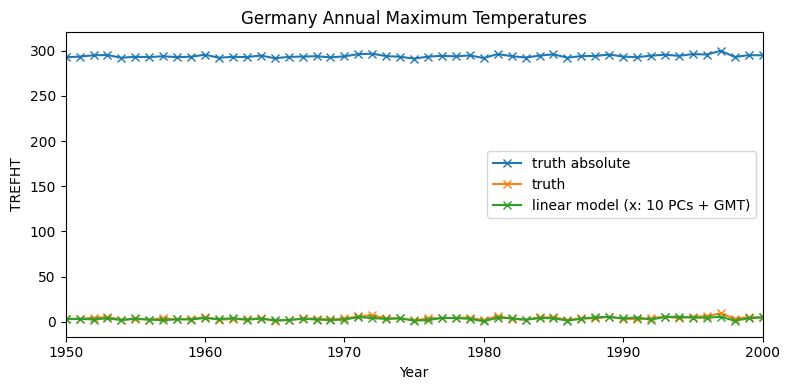

In [13]:
import pandas as pd


# anomalies ###
trefht_eth_ger_mean_1300 = trefht_eth_ger_mean.isel(time=slice(0,4769))
da_max_year_pre = trefht_eth_ger_mean_1300.groupby("time.year").max()

s = trefht_eth_ger_mean_1300.to_series()                      # pandas Series with DatetimeIndex
t_max = s.groupby(s.index.year).idxmax()

da_max_year = da_max_year_pre.assign_coords(year=(t_max.values))
da_max_year

# absolute temperatures ###
trefht_yearlymax_jja_ger_pre = trefht_5day_jja_ger.groupby("time.year").max()

s_abs = trefht_5day_jja_ger.to_series()                      # pandas Series with DatetimeIndex
t_max_abs = s_abs.groupby(s_abs.index.year).idxmax()

trefht_yearlymax_jja_ger = trefht_yearlymax_jja_ger_pre.assign_coords(year=(t_max.values))
trefht_yearlymax_jja_ger

##############################################

# integer indices in the original time axis (old, anomalies)
#time_index = pd.Index(trefht_eth_ger_mean_1300.time.values)
#idx = time_index.get_indexer(t_max.values)
#print(idx)

# integer indices in the original time axis (new, absolute values)
time_index_abs = pd.Index(trefht_5day_jja_ger.time.values)
idx_abs = time_index_abs.get_indexer(t_max_abs.values)
print(idx_abs)

# Plot ########

plt.figure(figsize=(8, 4))

# absolute temperatures test truth
#trefht_5day_jja_ger
plt.plot(
    da_max_year_pre.year.values,
    trefht_yearlymax_jja_ger.values,
    marker='x',
    label = "truth absolute"
)

# test truth anomalies
plt.plot(
    da_max_year_pre.year.values,
    da_max_year.values,
    marker='x',
    label = "truth"
)

# predictions
plt.plot(
    da_max_year_pre.year.values,
    y_pred_test_xr.isel(time=slice(0,4769)).isel(time=idx_abs),
    marker='x',
    label="linear model (x: 10 PCs + GMT)"
)

plt.xlabel("Year")
plt.ylabel(trefht_eth_ger_mean.name if trefht_eth_ger_mean.name is not None else "Value")
plt.title("Germany Annual Maximum Temperatures")

plt.xlim(1950, 2000)
plt.legend()
plt.tight_layout()

#plt.savefig("figures/dynanical_adjustment_ts.pdf")
plt.show()

In [14]:
# save absolute max indices
# np.save("yearly_absolute_max_indices_ger.npy", idx_abs)

# load it back in
arr = np.load("yearly_absolute_max_indices_ger.npy")

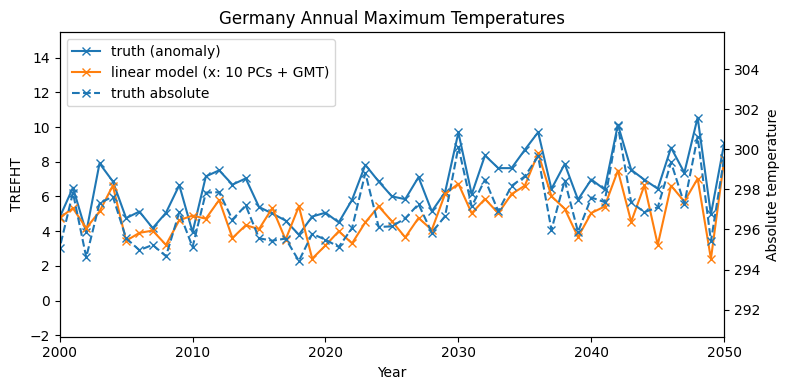

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

# --- left axis: anomalies / modeled ---
ax.plot(
    da_max_year_pre.year.values,
    da_max_year.values,
    marker="x",
    label="truth (anomaly)"
)

ax.plot(
    da_max_year_pre.year.values,
    y_pred_test_xr.isel(time=slice(0,4769)).isel(time=idx_abs),
    marker="x",
    label="linear model (x: 10 PCs + GMT)"
)

ax.set_xlabel("Year")
ax.set_ylabel(trefht_eth_ger_mean.name if trefht_eth_ger_mean.name is not None else "Anomaly")
#ax.set_xlim(1950,2000)
ax.set_xlim(2000, 2050)

# --- right axis: absolute temperatures ---
ax_abs = ax.twinx()

ax_abs.plot(
    da_max_year_pre.year.values,
    trefht_yearlymax_jja_ger.values,
    marker="x",
    linestyle="--",
    label="truth absolute"
)

ax_abs.set_ylabel("Absolute temperature")

# --- combined legend ---
lines_l, labels_l = ax.get_legend_handles_labels()
lines_r, labels_r = ax_abs.get_legend_handles_labels()
ax.legend(lines_l + lines_r, labels_l + labels_r, loc="upper left")

ax.set_title("Germany Annual Maximum Temperatures")
plt.tight_layout()
plt.show()


In [16]:
import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/data_exploration')

import utils as ut
import pytorch_quantile_regression as pqr


# show quantile regression model 
# ---- Load metadata ----
model_path = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/baseline_quantile_regression/v4_data_quantile_regression_ger_gradient_descent_2025-12-08_14-39/"
with open(f"{model_path}metadata.json", "r") as f:
    meta = json.load(f)

quantiles = meta["quantiles"]
n_features = meta["n_features"]
n_quantiles = len(quantiles)

# ---- Load checkpoint ----
ckpt_path = meta["last_checkpoint"]
checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)

# ---- Rebuild model ----
model = pqr.LinearMultiQuantileRegressor(
    n_features=n_features,
    n_quantiles=n_quantiles
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# ---- Move to GPU (optional) ----
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

In [17]:
# ---- Prepare test data ----
# load my data
settings_file_path = f"../joint_training/v4_dpa_train_settings.json" #used v2 here for a long time

with open(settings_file_path, 'r') as file:
        settings = json.load(file)

# Load Z500 data
z500_test = xr.open_dataset(settings['dataset_z500_eth_test']).pseudo_pcs

print("v1 data, still standardized here")
z500_test_np, _, _ = ut.standardize_numpy(z500_test.values)
X_test_torch = torch.from_numpy(z500_test_np.astype("float32")).to(device)
print(X_test_torch.shape)

if False:
    X_test_torch[:,-1] = -0.7389813694652794
# ---- Predict from Qu. regression model ----
with torch.no_grad():
    preds = model(X_test_torch)   # shape (N_test, n_quantiles)
quantile_predictions = preds.cpu().numpy()

print(preds.shape)
quantile_predictions = preds.cpu().numpy()
print("quantile predictions:", quantile_predictions)

# Temperature Test data
if False:
    trefht_eth = xr.open_dataset(settings['dataset_trefht_eth_nudged_shifted'])
else:
    trefht_eth = xr.open_dataset(settings['dataset_trefht_eth_transient'])
print(trefht_eth)

print("##############")
print("###Datasets###")
print("##############")
print(xr.open_dataset(settings['dataset_trefht_eth_nudged_shifted']))
print(xr.open_dataset(settings['dataset_trefht_eth_transient']))

# germany domain 
### Germany ###
    
# coordinates 
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15

# cut test data
#trefht_eth_ger = trefht_eth.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))
#print(trefht_eth_ger)

# calculate weighted means
#weights
#weights_ger_pre = np.cos(np.deg2rad(trefht_eth["lat"]))
#weights_ger = weights_ger_pre / weights_ger_pre.sum()

# test_data
#trefht_eth_ger_mean = trefht_eth_ger.TREFHT.weighted(weights_ger).mean(dim=("lat", "lon")).values
#print("Nans in trefht nudged/number:", np.isnan(trefht_eth_ger_mean).any(), np.isnan(trefht_eth_ger_mean).sum())


# prepare data for validation 
#X_test_np = z500_test_np
#y_test_np = trefht_eth_ger_mean
quantiles = meta["quantiles"]


v1 data, still standardized here
torch.Size([14307, 1001])
torch.Size([14307, 19])
quantile predictions: [[-8.464653  -8.005081  -7.8127227 ... -5.9170866 -5.734497  -5.103531 ]
 [-5.403062  -5.099936  -4.797727  ... -2.5863822 -2.3307528 -2.1194155]
 [-3.647561  -3.300338  -3.1253242 ... -1.5552533 -1.3243556 -1.0073192]
 ...
 [ 3.056892   3.700182   3.943797  ...  6.9657373  7.286297   7.697755 ]
 [ 3.5879989  4.062786   4.4090333 ...  7.081297   7.409769   7.9345703]
 [ 2.0411756  2.4464872  2.8968797 ...  5.270737   5.610327   6.074857 ]]
<xarray.Dataset> Size: 59MB
Dimensions:  (lat: 32, lon: 32, time: 14307)
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * time     (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 59MB ...
##############
###Datasets###
##############
<xarray.Dataset> Size: 59MB

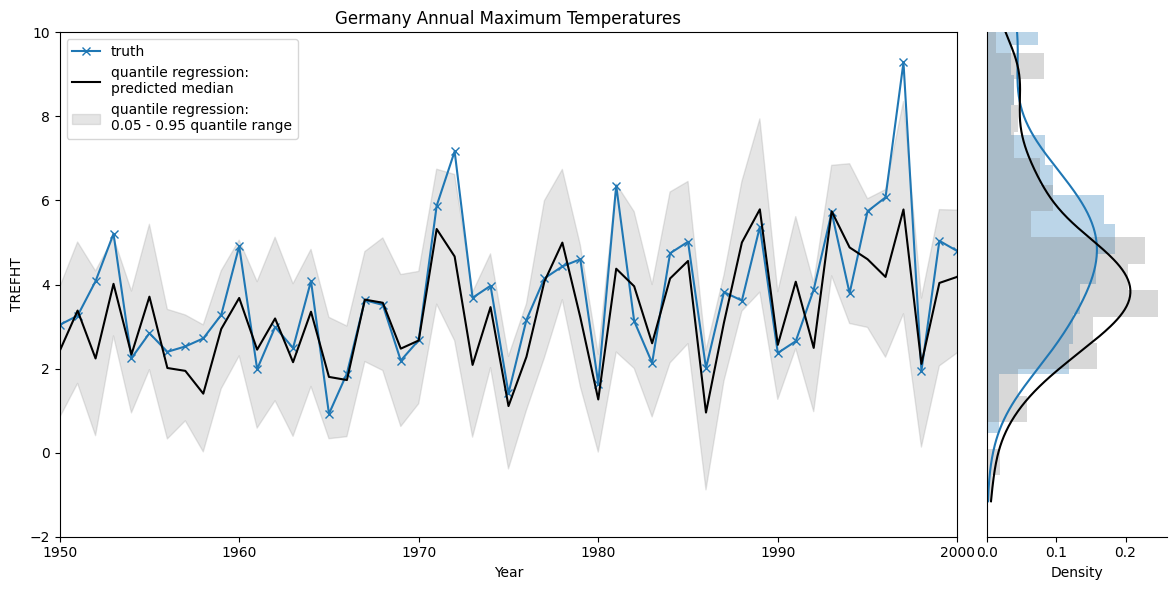

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(12, 6))

# --- main time series ---

# true test temperature series at yearly max absolute temperatures (idx_abs)
ax.plot(
    da_max_year_pre.year.values,
    trefht_eth_ger_mean_1300.values[idx_abs],
    marker="x",
    label="truth"
)

# linearly predicted temperatures
#ax.plot(
#    da_max_year_pre.year.values,
#    y_pred_test_xr.isel(time=slice(0,4769)).isel(time=idx_abs),
#    marker="x",
#    label="linear model (x: 10 PCs + GMT)"
#)

# quantile predictions with quantile interval (0.05-0.95)
ax.plot(da_max_year_pre.year.values, quantile_predictions[0:4769,9][idx_abs], label = 'quantile regression:\npredicted median', color='k')
ax.fill_between(
    da_max_year_pre.year.values,   # x-axis values (datetime64)
    quantile_predictions[0:4769,0][idx_abs],        # lower bound
    quantile_predictions[0:4769,18][idx_abs],        # upper bound
    color="grey", alpha=0.2, label=f"quantile regression:\n0.05 - 0.95 quantile range"
)

ax.set_xlabel("Year")
ax.set_ylabel(trefht_eth_ger_mean.name or "Value")
ax.set_title("Germany Annual Maximum Temperatures")
ax.set_xlim(1950, 2000)
ax.legend(loc="upper left")

# --- create a separate marginal axis on the RIGHT ---
divider = make_axes_locatable(ax)
#ax_dist = divider.append_axes("right", size="20%", pad=0.1, sharey=ax)

divider = make_axes_locatable(ax)
ax_dist = divider.append_axes(
    "right",
    size="20%",
    pad=0.3,   # ← increase this value to add more space
    sharey=ax
)

# --- data ---
truth_vals = trefht_eth_ger_mean_1300.values[idx_abs] #da_max_year.values
model_vals = y_pred_test_xr.isel(time=slice(0,4769)).isel(time=idx_abs).values #linear model
model_vals = quantile_predictions[0:4769,9][idx_abs]

y_grid = np.linspace(
    min(truth_vals.min(), model_vals.min()),
    max(truth_vals.max(), model_vals.max()),
    400
)

# KDEs
truth_kde = gaussian_kde(truth_vals)
model_kde = gaussian_kde(model_vals)

# Histograms (horizontal)
ax_dist.hist(
    truth_vals,
    bins=20,
    orientation="horizontal",
    density=True,
    alpha=0.3,
    color="tab:blue"
)

ax_dist.hist(
    model_vals,
    bins=20,
    orientation="horizontal",
    density=True,
    alpha=0.3,
    color="grey"
)

# KDE lines
ax_dist.plot(truth_kde(y_grid), y_grid, color="tab:blue")
ax_dist.plot(model_kde(y_grid), y_grid, color="black")

# --- styling: marginal only ---
ax_dist.set_xlabel("Density")
ax_dist.yaxis.set_visible(False)
ax_dist.spines["top"].set_visible(False)
ax_dist.spines["right"].set_visible(False)

plt.tight_layout()
plt.ylim(-2,10)
plt.savefig("figures/fig01.pdf")
plt.show()
